In [6]:
import sys
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.append('../src')

import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Risultati ottenuti dal training con 5 epoche
results = {
    'A': {'auc': 0.9997, 'precision': 0.9842, 'recall': 0.9964, 'f1': 0.9903, 'accuracy': 0.9886},
    'B': {'auc': 0.9520, 'precision': 0.9392, 'recall': 0.5951, 'f1': 0.7286, 'accuracy': 0.7430},
    'C': {'auc': 0.8037, 'precision': 0.1005, 'recall': 0.0103, 'f1': 0.0188, 'accuracy': 0.3729},
    'D': {'auc': 0.9270, 'precision': 1.0000, 'recall': 0.0004, 'f1': 0.0008, 'accuracy': 0.4208},
}

# Salva correttamente
with open('../outputs/results_5ep.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Risultati caricati e salvati correttamente.")
print(results)

Risultati caricati e salvati correttamente.
{'A': {'auc': 0.9997, 'precision': 0.9842, 'recall': 0.9964, 'f1': 0.9903, 'accuracy': 0.9886}, 'B': {'auc': 0.952, 'precision': 0.9392, 'recall': 0.5951, 'f1': 0.7286, 'accuracy': 0.743}, 'C': {'auc': 0.8037, 'precision': 0.1005, 'recall': 0.0103, 'f1': 0.0188, 'accuracy': 0.3729}, 'D': {'auc': 0.927, 'precision': 1.0, 'recall': 0.0004, 'f1': 0.0008, 'accuracy': 0.4208}}


In [7]:
print(results)

{'A': {'auc': 0.9997, 'precision': 0.9842, 'recall': 0.9964, 'f1': 0.9903, 'accuracy': 0.9886}, 'B': {'auc': 0.952, 'precision': 0.9392, 'recall': 0.5951, 'f1': 0.7286, 'accuracy': 0.743}, 'C': {'auc': 0.8037, 'precision': 0.1005, 'recall': 0.0103, 'f1': 0.0188, 'accuracy': 0.3729}, 'D': {'auc': 0.927, 'precision': 1.0, 'recall': 0.0004, 'f1': 0.0008, 'accuracy': 0.4208}}


Tabella comparativa

In [9]:
df_results = pd.DataFrame(results).T
df_results.index = [f'CONFIG_{c}' for c in df_results.index]
df_results.columns = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']

print("=== TABELLA COMPARATIVA ===")
print(df_results.round(4).to_string())

df_results.to_csv('../outputs/results_table.csv')
print("\nTabella salvata.")

=== TABELLA COMPARATIVA ===
             AUC  Precision  Recall      F1  Accuracy
CONFIG_A  0.9997     0.9842  0.9964  0.9903    0.9886
CONFIG_B  0.9520     0.9392  0.5951  0.7286    0.7430
CONFIG_C  0.8037     0.1005  0.0103  0.0188    0.3729
CONFIG_D  0.9270     1.0000  0.0004  0.0008    0.4208

Tabella salvata.


Grafico comparativo

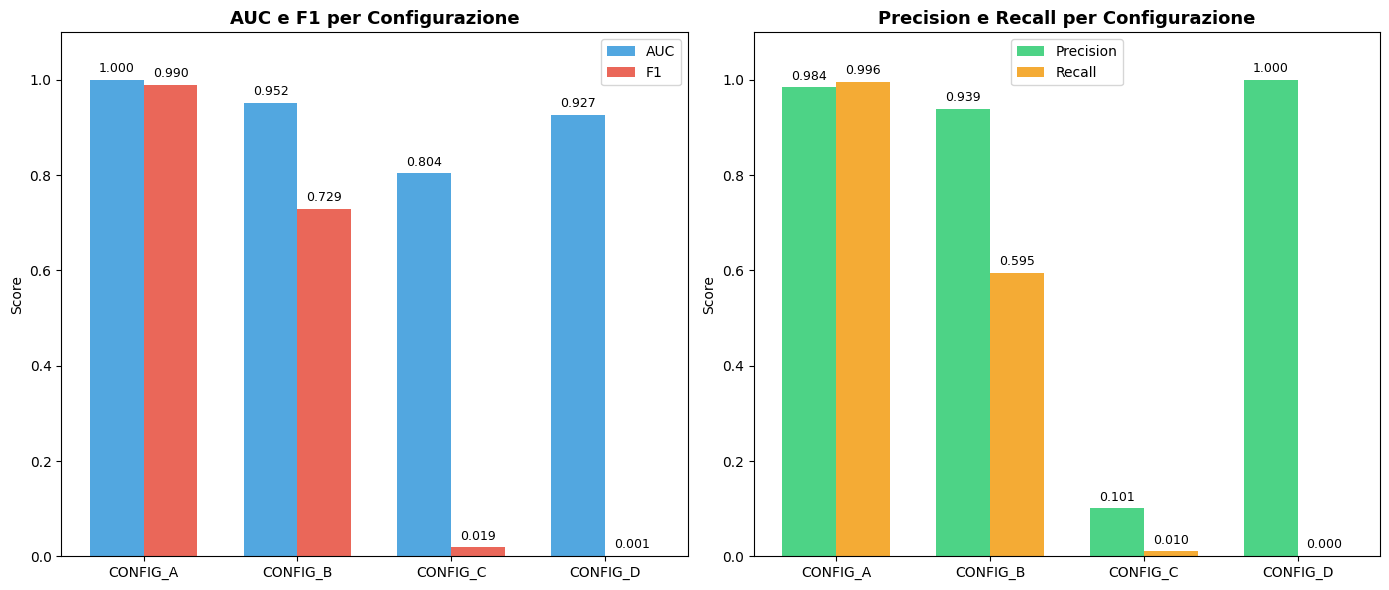

Figura salvata.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

configs = list(results.keys())
x = np.arange(len(configs))
width = 0.35
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
metrics_to_plot = ['AUC', 'F1', 'Precision', 'Recall', 'Accuracy']

# Grafico 1 — AUC e F1
auc_vals = [results[c]['auc'] for c in configs]
f1_vals  = [results[c]['f1'] for c in configs]

bars1 = axes[0].bar(x - width/2, auc_vals, width, label='AUC', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + width/2, f1_vals,  width, label='F1',  color='#e74c3c', alpha=0.85)

axes[0].set_title('AUC e F1 per Configurazione', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'CONFIG_{c}' for c in configs])
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Grafico 2 — Precision e Recall
prec_vals   = [results[c]['precision'] for c in configs]
recall_vals = [results[c]['recall'] for c in configs]

bars3 = axes[1].bar(x - width/2, prec_vals,   width, label='Precision', color='#2ecc71', alpha=0.85)
bars4 = axes[1].bar(x + width/2, recall_vals, width, label='Recall',    color='#f39c12', alpha=0.85)

axes[1].set_title('Precision e Recall per Configurazione', fontweight='bold', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'CONFIG_{c}' for c in configs])
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].set_ylabel('Score')

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata.")

Radar chart per per profilo di ogni configurazione

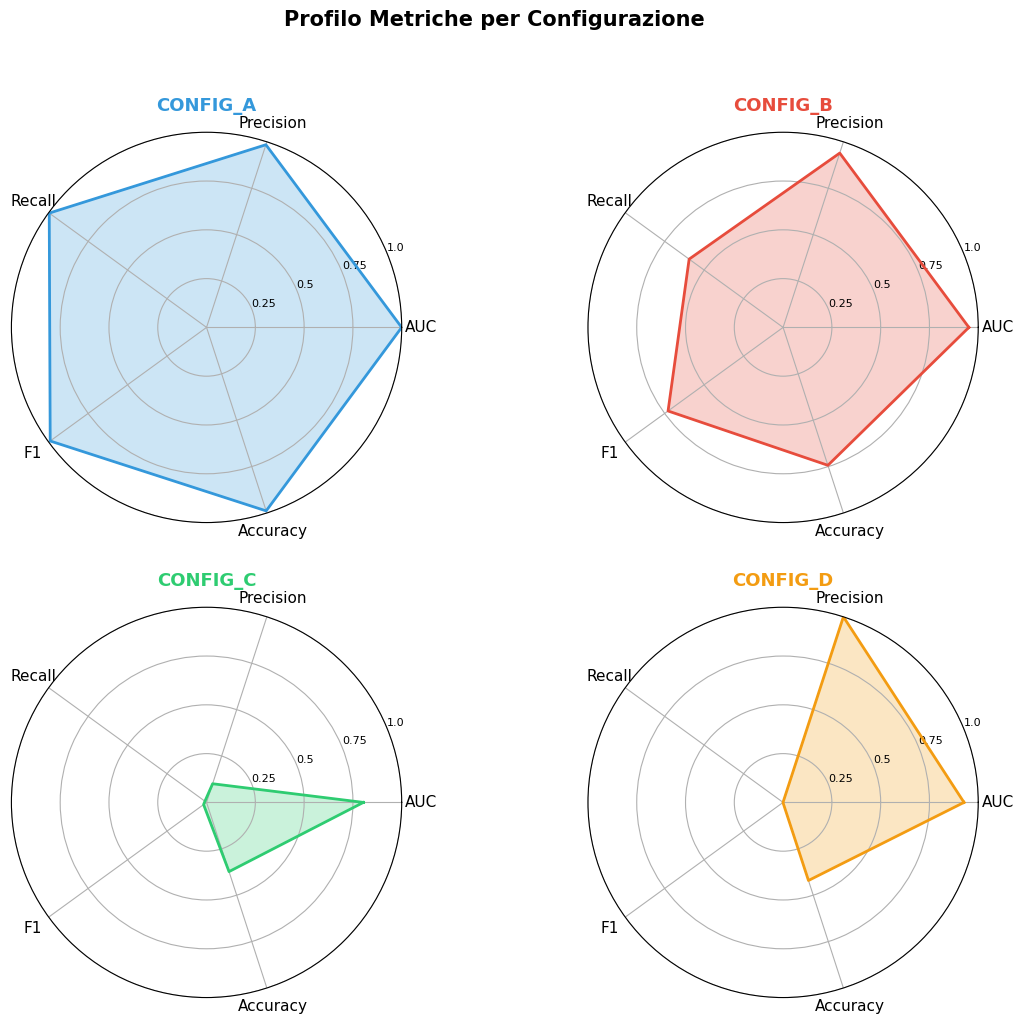

Figura salvata.


In [11]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (config, color) in enumerate(zip(configs, colors)):
    ax = axes[idx]
    
    values = [
        results[config]['auc'],
        results[config]['precision'],
        results[config]['recall'],
        results[config]['f1'],
        results[config]['accuracy']
    ]
    values += values[:1]
    
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(f'CONFIG_{config}', fontweight='bold',
                fontsize=13, pad=15, color=color)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8)

plt.suptitle('Profilo Metriche per Configurazione', 
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata.")

Visualizzazione del network con community

In [12]:
import networkx as nx
from utils import load_dataset, build_graph, run_lpa, WINDOW_HOURS
import pandas as pd

# Carica una finestra con anomalie
df = load_dataset('../data/ton_iot_20pct.csv')
df['window'] = df['Timestamp'].dt.floor(f'{WINDOW_HOURS}h')
window_counts = df.groupby('window').size()
valid_windows = window_counts[window_counts >= 100].index

# Prendi una finestra con anomalie — la 35esima (sappiamo che ha attacchi)
target_window = valid_windows[34]
window_df = df[df['window'] == target_window].copy()
G = build_graph(window_df, edge_types=['comm'])

print(f"Finestra: {target_window}")
print(f"Nodi: {G.number_of_nodes()}")
print(f"Archi totali: {G.number_of_edges()}")
print(f"Archi anomali: {sum(1 for u,v,d in G.edges(data=True) if d['label']==1)}")

# Applica LPA
community_map = run_lpa(G)
n_comm = len(set(community_map.values()))
print(f"Community: {n_comm}")

Finestra: 2019-04-27 14:00:00
Nodi: 177
Archi totali: 111104
Archi anomali: 78286
Community: 9


Visualizzazione network campionato

Nodi visualizzati: 166
Archi visualizzati: 33


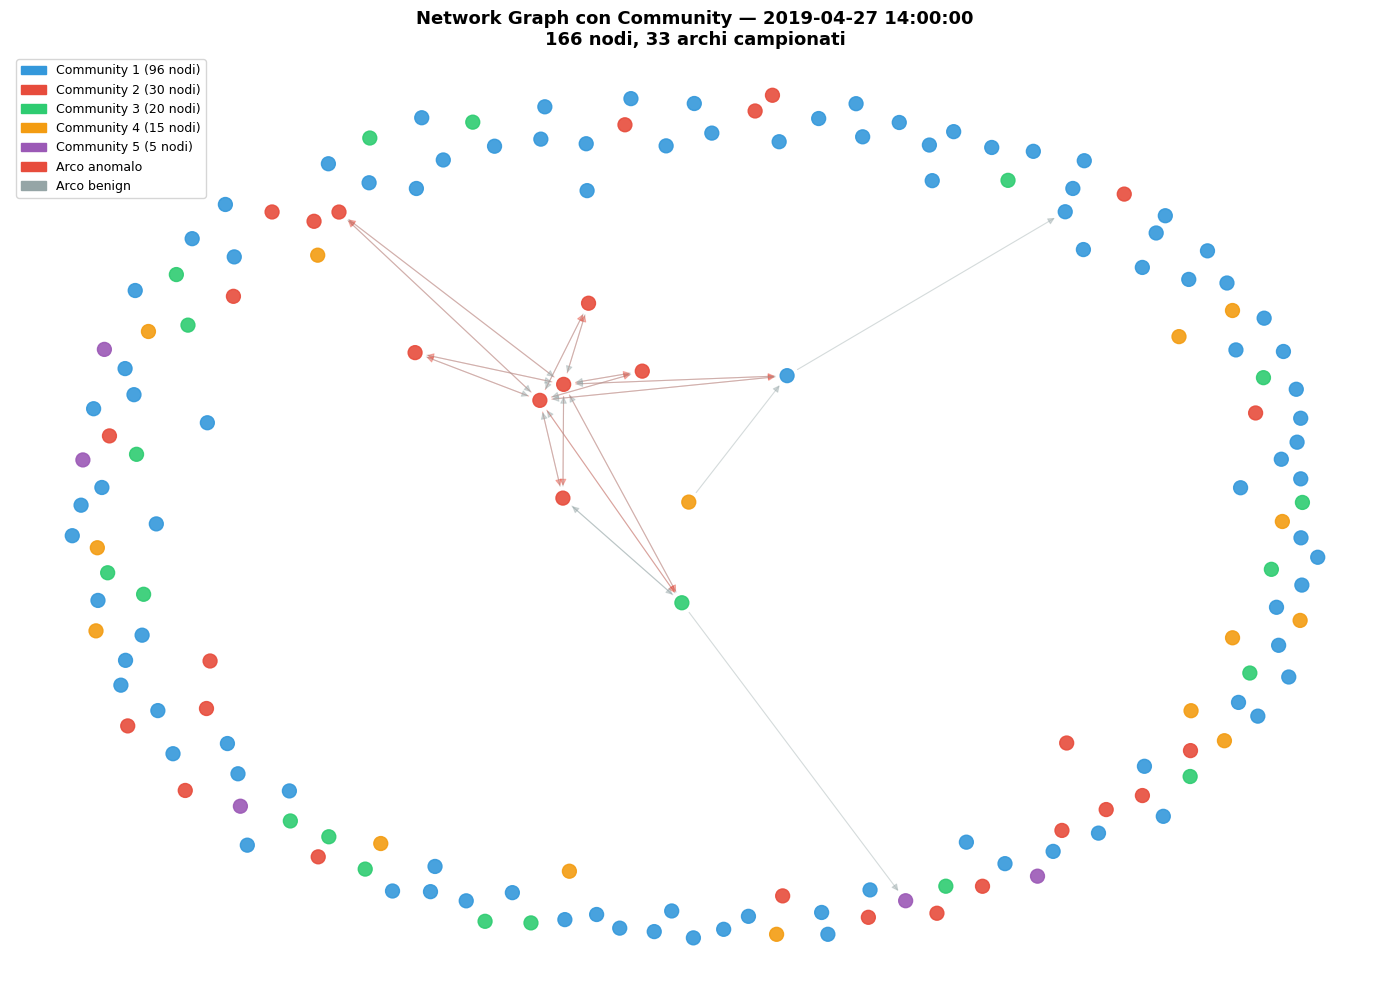

Figura salvata.


In [13]:
import random
random.seed(42)

# Prendi solo i nodi delle community più grandi
comm_sizes = {}
for node, comm_id in community_map.items():
    comm_sizes[comm_id] = comm_sizes.get(comm_id, 0) + 1

# Top 5 community per dimensione
top_communities = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
top_comm_ids = {c[0] for c in top_communities}

# Filtra nodi
nodes_to_show = [n for n, c in community_map.items() if c in top_comm_ids]

# Sottografo
G_sub = G.subgraph(nodes_to_show).copy()

# Campiona max 500 archi per leggibilità
all_edges = list(G_sub.edges(data=True))
if len(all_edges) > 500:
    sampled_edges = random.sample(all_edges, 500)
    G_vis = nx.DiGraph()
    G_vis.add_nodes_from(G_sub.nodes())
    G_vis.add_edges_from([(u, v) for u, v, d in sampled_edges])
else:
    G_vis = G_sub

print(f"Nodi visualizzati: {G_vis.number_of_nodes()}")
print(f"Archi visualizzati: {G_vis.number_of_edges()}")

# Colori per community
comm_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
color_map = {}
for i, (comm_id, _) in enumerate(top_communities):
    for node in nodes_to_show:
        if community_map[node] == comm_id:
            color_map[node] = comm_colors[i]

node_colors = [color_map.get(n, '#95a5a6') for n in G_vis.nodes()]

# Identifica archi anomali
anomaly_set = {(u, v) for u, v, d in sampled_edges if d.get('label') == 1}
edge_colors = ['#e74c3c' if (u,v) in anomaly_set else '#95a5a6' 
               for u, v in G_vis.edges()]

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_vis, seed=42, k=0.5)

nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors,
                       node_size=100, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_vis, pos, edge_color=edge_colors,
                       alpha=0.4, width=0.8, arrows=True,
                       arrowsize=10, ax=ax)

# Legenda
patches = [mpatches.Patch(color=comm_colors[i], 
                          label=f'Community {i+1} ({top_communities[i][1]} nodi)')
           for i in range(len(top_communities))]
patches.append(mpatches.Patch(color='#e74c3c', label='Arco anomalo'))
patches.append(mpatches.Patch(color='#95a5a6', label='Arco benign'))
ax.legend(handles=patches, loc='upper left', fontsize=9)

ax.set_title(f'Network Graph con Community — {target_window}\n'
             f'{G_vis.number_of_nodes()} nodi, {G_vis.number_of_edges()} archi campionati',
             fontweight='bold', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/network_communities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata.")